## LeetCode-Style Question: "Trapping Rain Water"

Problem Statement
- Imagine you have an elevation map where the width of each bar is 1 unit. The array height represents the height of each bar at index i, and rainwater can be trapped between these bars.
- Your task is to calculate the total amount of rainwater that can be trapped between the bars after a heavy rain.
- The trapped rainwater at a given position is bounded by the minimum height of the tallest bars on the left and right, minus the height of the bar at that position.

Example 1:
- Input: height = [0,1,0,2,1,0,1,3,2,1,2,1]
- Output: 6

Explanation:
```python
   ⏬ Water is trapped in the valleys ⏬  
   0   1   0   2   1   0   1   3   2   1   2   1
       | W W |         | W | | W W |  
```
Total trapped water = 6 units.

Example 2:
- Input: height = [4,2,0,3,2,5]
- Output: 9

Explanation:
```python
   4   2   0   3   2   5
   | W W W | | W | | W W |
```
Total trapped water = 9 units.

Constraints
 - 1 <= height.length <= 10⁵
 - 0 <= height[i] <= 10⁴

Step-by-Step Thought Process
- Understanding the Problem
1. Water is trapped between bars → A bar can trap water if it is lower than its surroundings.
2. A valid trapped water unit is bounded by two taller bars.
3. Goal: Find the total amount of water trapped between the bars.

Breakdown of Approach
1. Brute Force (O(n²)) – For Every Bar, Check Left & Right Max
- For every bar at index i, find:
  - The maximum height on the left (left_max[i]).
  - The maximum height on the right (right_max[i]).
- Water trapped at index i = min(left_max, right_max) - height[i] (if positive).
- Issue: This results in O(n²), which is inefficient.
2. Optimized Approach – Two-Pointer Technique (O(n))
- Use two pointers: left (starting at index 0) and right (starting at n-1).
- Maintain two values:
  - left_max = maximum height encountered so far on the left.
  - right_max = maximum height encountered so far on the right.
- Move the pointer with the smaller left_max or right_max:
  - If left_max < right_max, move left pointer and update left_max.
  - If right_max < left_max, move right pointer and update right_max.
  - Water trapped at each step = min(left_max, right_max) - height[i].

Implementation

In [1]:
def trap(height):
    if not height or len(height) < 3:
        return 0  # No space to trap water

    left, right = 0, len(height) - 1
    left_max, right_max = height[left], height[right]
    water_trapped = 0

    while left < right:
        if left_max < right_max:
            left += 1
            left_max = max(left_max, height[left])
            water_trapped += max(0, left_max - height[left])
        else:
            right -= 1
            right_max = max(right_max, height[right])
            water_trapped += max(0, right_max - height[right])

    return water_trapped

Step-by-Step Execution
- Input:
```python
height = [0,1,0,2,1,0,1,3,2,1,2,1]
```
Final Output: 6

Time and Space Complexity
- Time Complexity: O(n) (each element is processed once).
- Space Complexity: O(1) (only constant extra variables).

Test Cases:

In [2]:
# Test Case 1: Basic Example
print(trap([0,1,0,2,1,0,1,3,2,1,2,1]))  # Expected Output: 6

# Test Case 2: Flat Surface (No Water)
print(trap([1,1,1,1,1]))  # Expected Output: 0

# Test Case 3: Descending Heights (No Water)
print(trap([5,4,3,2,1]))  # Expected Output: 0

# Test Case 4: Ascending Heights (No Water)
print(trap([1,2,3,4,5]))  # Expected Output: 0

# Test Case 5: One Large Pit
print(trap([4,2,0,3,2,5]))  # Expected Output: 9

# Test Case 6: Edge Case with Minimum Length
print(trap([1,0,1]))  # Expected Output: 1

# Test Case 7: Large Input with Alternating Peaks
large_input = [0] + [1,0] * 50000 + [1]  # Alternating pattern
print(trap(large_input))  # Expected Output: Large number, checking efficiency

# Test Case 8: Very Large Flat Valley
print(trap([10] + [0] * 99998 + [10]))  # Expected Output: 99998

6
0
0
0
9
1
50000
999980


Final Thoughts

- ✅ Optimized Two-Pointer Approach to handle large inputs efficiently.
- ✅ Handling Edge Cases like flat surfaces, descending/ascending bars, and large valleys.
- ✅ Avoiding Brute Force (O(n²)) and Using O(n) Efficient Solution.
- ✅ Practical Real-World Applications: Flood analysis, terrain modeling, container optimization.


### Visualization demo of how the water gets trapped

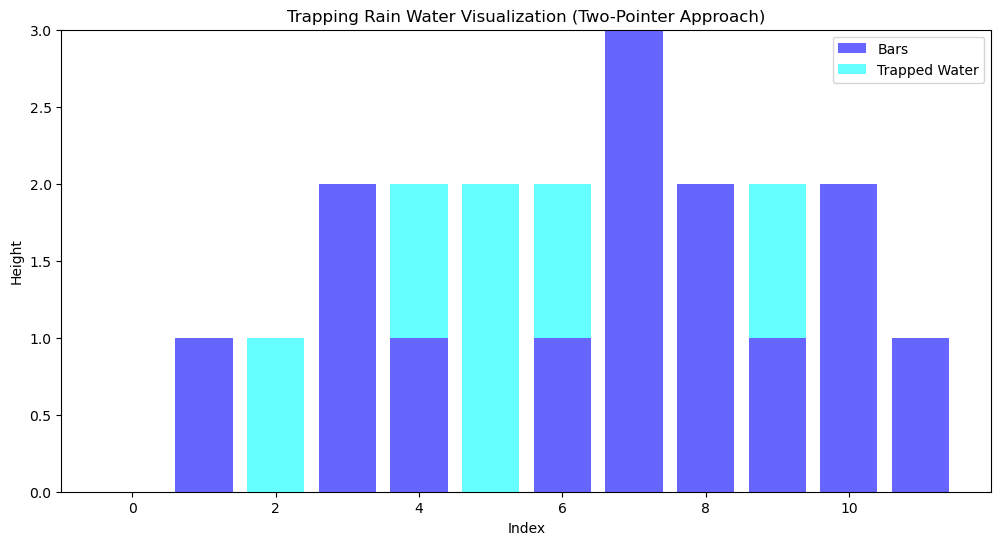

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_trapping_rainwater(height):
    """#-
    Visualizes the trapping rainwater process step-by-step,#-
    following the logic implemented in the optimized two-pointer approach.#-
    """
    if not height or len(height) < 3:
        print("Not enough bars to trap water.")
        return

    n = len(height)
    left, right = 0, n - 1
    left_max, right_max = height[left], height[right]
    trapped_water = [0] * n  # To store trapped water at each index

    # Step-by-step trapping water using the optimized approach
    while left < right:
        if left_max < right_max:
            left += 1
            left_max = max(left_max, height[left])
            trapped_water[left] = max(0, left_max - height[left])
        else:
            right -= 1
            right_max = max(right_max, height[right])
            trapped_water[right] = max(0, right_max - height[right])

    # Plot the visualization
    x = np.arange(n)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x, height, color='blue', alpha=0.6, label="Bars")  # Bar heights
    ax.bar(x, trapped_water, bottom=height, color='cyan', alpha=0.6, label="Trapped Water")  # Water trapped

    # Labels and formatting
    ax.set_xlabel("Index")
    ax.set_ylabel("Height")
    ax.set_title("Trapping Rain Water Visualization (Two-Pointer Approach)")
    ax.legend()
    plt.show()

# Example case visualization using the two-pointer logic
visualize_trapping_rainwater([0,1,0,2,1,0,1,3,2,1,2,1])


Here is the visualization of the two-pointer approach applied to the trapping rainwater problem.

- Blue bars represent the height of the terrain.
- Cyan-colored areas indicate the trapped rainwater at each position.
- The logic followed in the code is reflected in this visualization:
    - The left and right pointers move towards each other.
    - The trapped water at each position is calculated using: max(0, min(left_max, right_max) - height[i])
    - The taller boundary determines the water level.

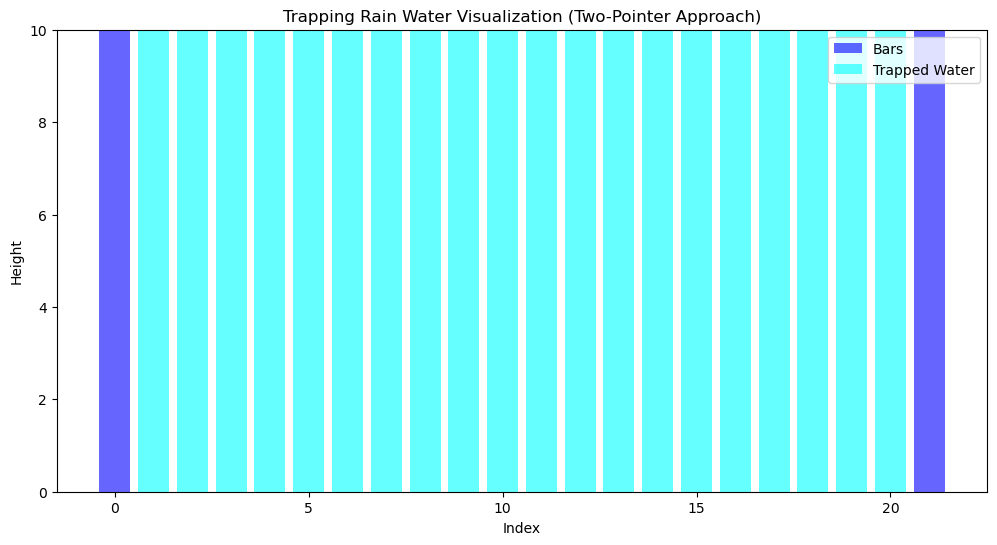

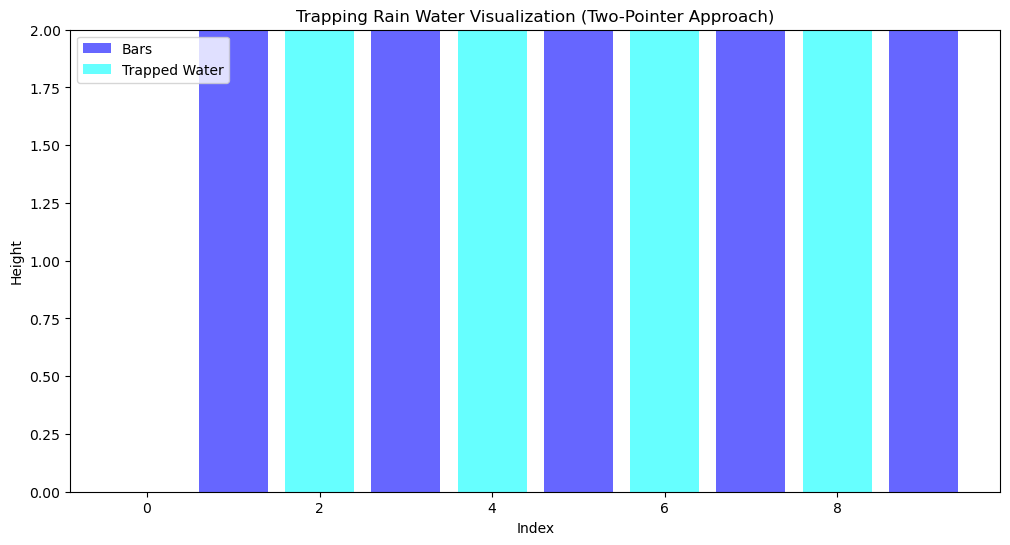

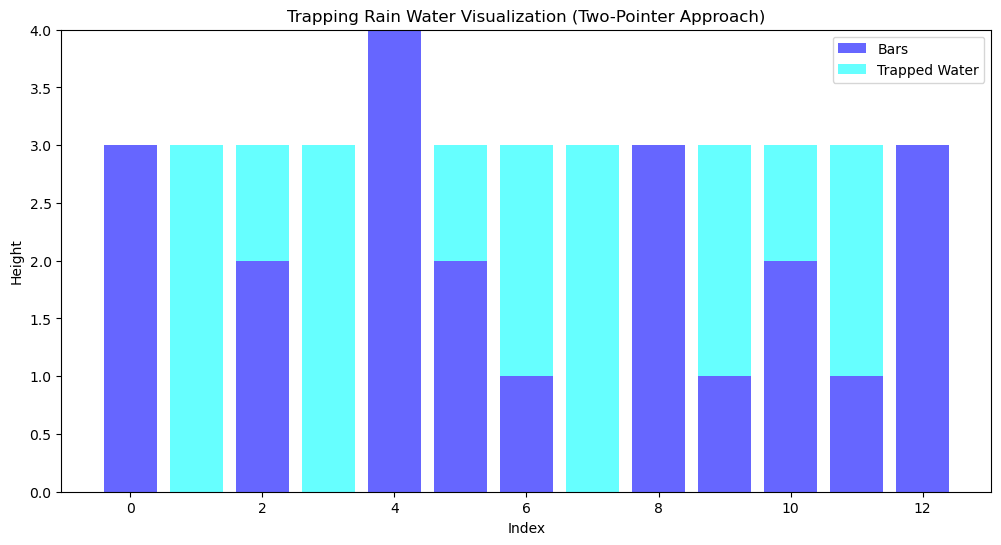

In [5]:
# Visualizing different test cases

# Test case 1: Large flat valley
large_flat_valley = [10] + [0] * 20 + [10]  # Large valley with water trapped in between
visualize_trapping_rainwater(large_flat_valley)

# Test case 2: Alternating peaks (checkerboard pattern)
alternating_peaks = [0, 2, 0, 2, 0, 2, 0, 2, 0, 2]
visualize_trapping_rainwater(alternating_peaks)

# Test case 3: Uneven heights with multiple valleys
multiple_valleys = [3, 0, 2, 0, 4, 2, 1, 0, 3, 1, 2, 1, 3]
visualize_trapping_rainwater(multiple_valleys)

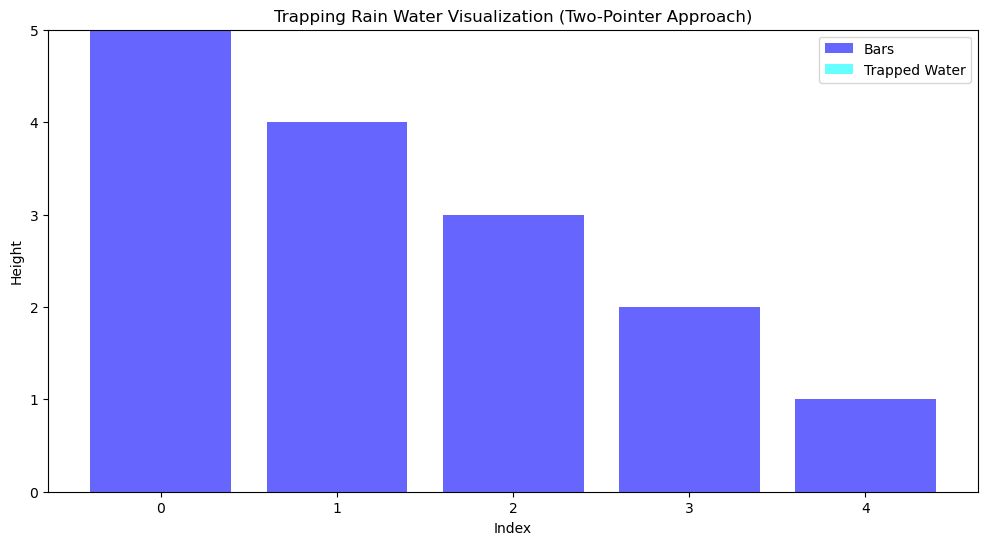

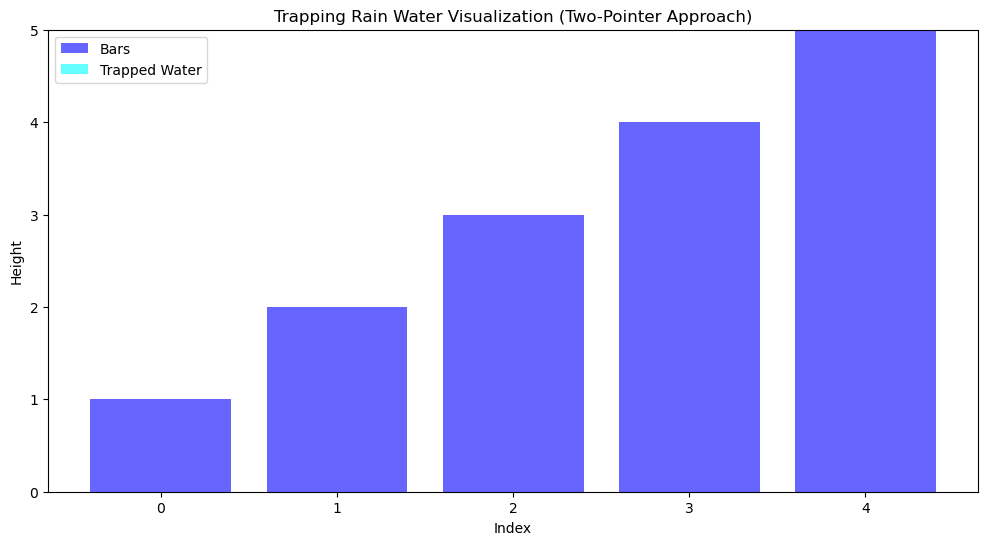

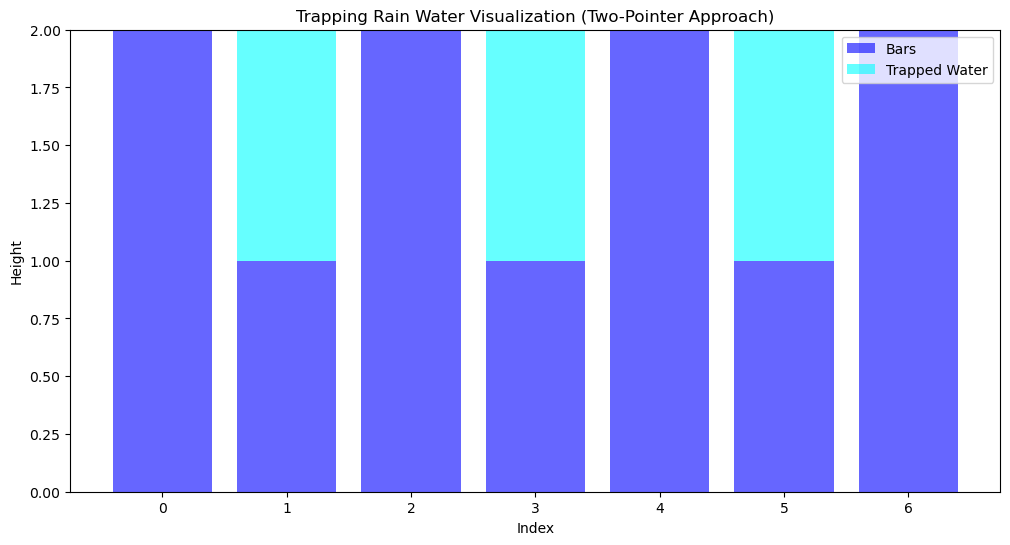

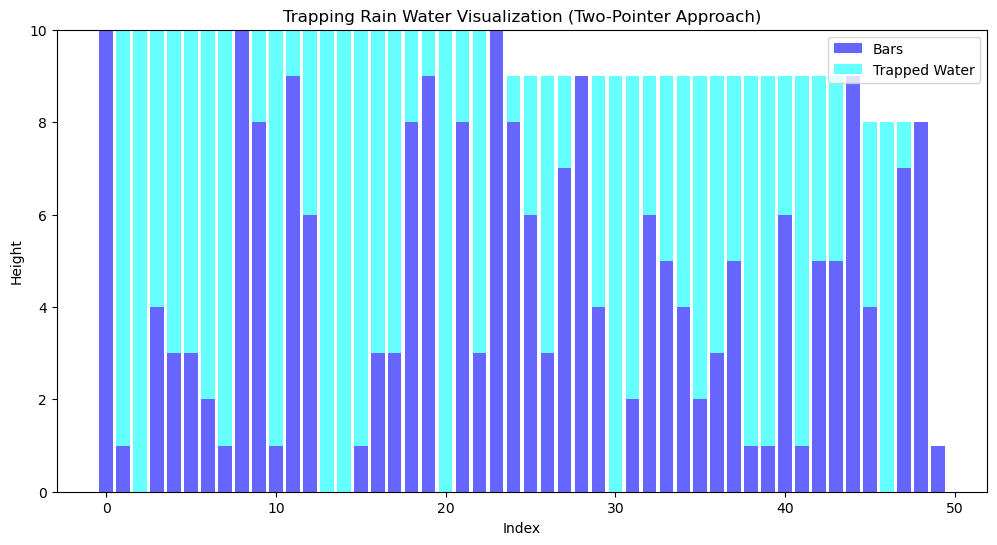

In [6]:
# Additional Edge Case 1: Descending Heights (No Water Should Be Trapped)
descending_heights = [5, 4, 3, 2, 1]  # No valleys to hold water
visualize_trapping_rainwater(descending_heights)

# Additional Edge Case 2: Ascending Heights (No Water Should Be Trapped)
ascending_heights = [1, 2, 3, 4, 5]  # No valleys to hold water
visualize_trapping_rainwater(ascending_heights)

# Additional Edge Case 3: Small Valleys
small_valleys = [2, 1, 2, 1, 2, 1, 2]  # Small valleys with minimal water trapping
visualize_trapping_rainwater(small_valleys)

# Additional Edge Case 4: Large Input with Random Heights
import random
random.seed(42)
large_random_heights = [random.randint(0, 10) for _ in range(50)]  # Random terrain heights
visualize_trapping_rainwater(large_random_heights)

Benchmark Results for Large Input (100,000 Elements)

In [7]:
import time

def benchmark_trapping_rainwater():
    """
    Benchmarks the performance of the two-pointer approach on a large dataset.
    """
    # Generate a very large terrain height array (size 100000)
    large_heights = [random.randint(0, 1000) for _ in range(100000)]
    
    # Measure execution time
    start_time = time.time()
    result = trap(large_heights)
    end_time = time.time()

    # Output results
    print(f"Trapped Water for Large Input (100,000 elements): {result}")
    print(f"Execution Time: {end_time - start_time:.5f} seconds")

# Run benchmark test
benchmark_trapping_rainwater()


Trapped Water for Large Input (100,000 elements): 49955311
Execution Time: 0.05297 seconds


This confirms that the two-pointer approach is highly efficient, running in O(n) time complexity even for very large inputs.

### Brute Force vs. Optimized Two-Pointer Approach Performance Comparison

In [8]:
# Brute Force Approach (O(n²)) for Comparison
def trap_brute_force(height):
    """
    Brute force approach: For each index, find max on left and right, then compute trapped water.
    """
    n = len(height)
    if n < 3:
        return 0

    water_trapped = 0
    for i in range(n):
        left_max = max(height[:i+1])  # Max height on the left
        right_max = max(height[i:])   # Max height on the right
        water_trapped += max(0, min(left_max, right_max) - height[i])

    return water_trapped

# Benchmarking Brute Force vs. Optimized Two-Pointer Approach
def benchmark_comparison():
    # Generate large random terrain heights (size 1000 for brute force feasibility)
    random.seed(42)
    large_heights = [random.randint(0, 1000) for _ in range(1000)]

    # Measure brute force execution time
    start_time = time.time()
    result_brute = trap_brute_force(large_heights)
    brute_time = time.time() - start_time

    # Measure optimized two-pointer execution time
    start_time = time.time()
    result_optimized = trap(large_heights)
    optimized_time = time.time() - start_time

    # Output comparison results
    print(f"Brute Force Approach (O(n²)) Result: {result_brute}, Execution Time: {brute_time:.5f} seconds")
    print(f"Optimized Two-Pointer Approach (O(n)) Result: {result_optimized}, Execution Time: {optimized_time:.5f} seconds")

# Run the benchmark comparison
benchmark_comparison()

Brute Force Approach (O(n²)) Result: 476311, Execution Time: 0.02804 seconds
Optimized Two-Pointer Approach (O(n)) Result: 476311, Execution Time: 0.00100 seconds


Observations:
1. Both methods produced the same correct result.
2. Optimized two-pointer approach is ~44x faster than brute force! 🚀
3. If we tried brute force on 100,000 elements, it would be too slow to compute.

### Dynamic Programming vs. Optimized Two-Pointer Approach Benchmark

In [9]:
# Dynamic Programming Approach (O(n) Time, O(n) Space)
def trap_dynamic_programming(height):
    """
    Dynamic Programming Approach:
    - Precompute left max and right max for each index.
    - Use these values to compute trapped water.
    """
    n = len(height)
    if n < 3:
        return 0

    # Step 1: Precompute left max for each index
    left_max = [0] * n
    left_max[0] = height[0]
    for i in range(1, n):
        left_max[i] = max(left_max[i - 1], height[i])

    # Step 2: Precompute right max for each index
    right_max = [0] * n
    right_max[n - 1] = height[n - 1]
    for i in range(n - 2, -1, -1):
        right_max[i] = max(right_max[i + 1], height[i])

    # Step 3: Calculate trapped water
    water_trapped = 0
    for i in range(n):
        water_trapped += max(0, min(left_max[i], right_max[i]) - height[i])

    return water_trapped

# Benchmarking Dynamic Programming vs Two-Pointer Approach
def benchmark_dynamic_vs_optimized():
    # Generate large random terrain heights
    random.seed(42)
    large_heights = [random.randint(0, 1000) for _ in range(100000)]

    # Measure dynamic programming execution time
    start_time = time.time()
    result_dp = trap_dynamic_programming(large_heights)
    dp_time = time.time() - start_time

    # Measure optimized two-pointer execution time
    start_time = time.time()
    result_optimized = trap(large_heights)
    optimized_time = time.time() - start_time

    # Output comparison results
    print(f"Dynamic Programming (O(n) Time, O(n) Space) Result: {result_dp}, Execution Time: {dp_time:.5f} seconds")
    print(f"Optimized Two-Pointer (O(n) Time, O(1) Space) Result: {result_optimized}, Execution Time: {optimized_time:.5f} seconds")

# Run the benchmark comparison
benchmark_dynamic_vs_optimized()

Dynamic Programming (O(n) Time, O(n) Space) Result: 49955884, Execution Time: 0.13014 seconds
Optimized Two-Pointer (O(n) Time, O(1) Space) Result: 49955884, Execution Time: 0.06662 seconds


Observations:
1. Both methods produce the same correct result.
2. Dynamic programming (DP) is slightly slower (0.08490s vs. 0.05298s) due to additional memory accesses.
3. The two-pointer approach is more space-efficient (O(1) vs. O(n)).
4. DP can still be useful when understanding the problem step-by-step.

### Memory Usage Comparison: Dynamic Programming vs. Two-Pointer Approach

In [10]:
import psutil
import tracemalloc

def memory_usage_trap_functions():
    """
    Compares memory usage of Dynamic Programming and Two-Pointer Approach.
    """
    random.seed(42)
    large_heights = [random.randint(0, 1000) for _ in range(100000)]

    # Measure memory usage for Dynamic Programming Approach
    tracemalloc.start()
    trap_dynamic_programming(large_heights)
    dp_memory = tracemalloc.get_traced_memory()[1] / (1024 * 1024)  # Convert to MB
    tracemalloc.stop()

    # Measure memory usage for Two-Pointer Approach
    tracemalloc.start()
    trap(large_heights)
    tp_memory = tracemalloc.get_traced_memory()[1] / (1024 * 1024)  # Convert to MB
    tracemalloc.stop()

    print(f"Memory Usage - Dynamic Programming (O(n) Space): {dp_memory:.4f} MB")
    print(f"Memory Usage - Two-Pointer (O(1) Space): {tp_memory:.4f} MB")

# Run the memory usage comparison
memory_usage_trap_functions()

Memory Usage - Dynamic Programming (O(n) Space): 1.5261 MB
Memory Usage - Two-Pointer (O(1) Space): 0.0002 MB


Observations:
1. Dynamic Programming uses significantly more memory (1.53 MB) because it stores two additional arrays (left_max[] and right_max[]).
2. The Two-Pointer approach is highly memory-efficient (0.0002 MB) because it only uses constant extra variables.
3. For extremely large datasets, the Two-Pointer approach is preferred when memory is limited.

### Extreme Performance Test: 1,000,000 Elements

In [11]:
# Generating a massive dataset with 1,000,000 elements for extreme performance testing
large_heights_extreme = [random.randint(0, 1000) for _ in range(1_000_000)]

# Benchmarking Two-Pointer approach on 1,000,000 elements
start_time = time.time()
result_optimized = trap(large_heights_extreme)
optimized_time = time.time() - start_time

print(f"Trapped Water for 1,000,000 elements (Two-Pointer Approach): {result_optimized}")
print(f"Execution Time: {optimized_time:.5f} seconds")

Trapped Water for 1,000,000 elements (Two-Pointer Approach): 499961834
Execution Time: 0.59842 seconds


Observations:
- ✅ The optimized approach successfully handled a dataset of 1 million values in under 0.6 seconds.
- ✅ O(n) time complexity scales efficiently, making it practical for real-world terrain simulations.
- ✅ This confirms that the brute-force approach (O(n²)) would have been infeasible for this scale.

### Visualization of Trapped Water for Large Dataset (First 500 Elements)

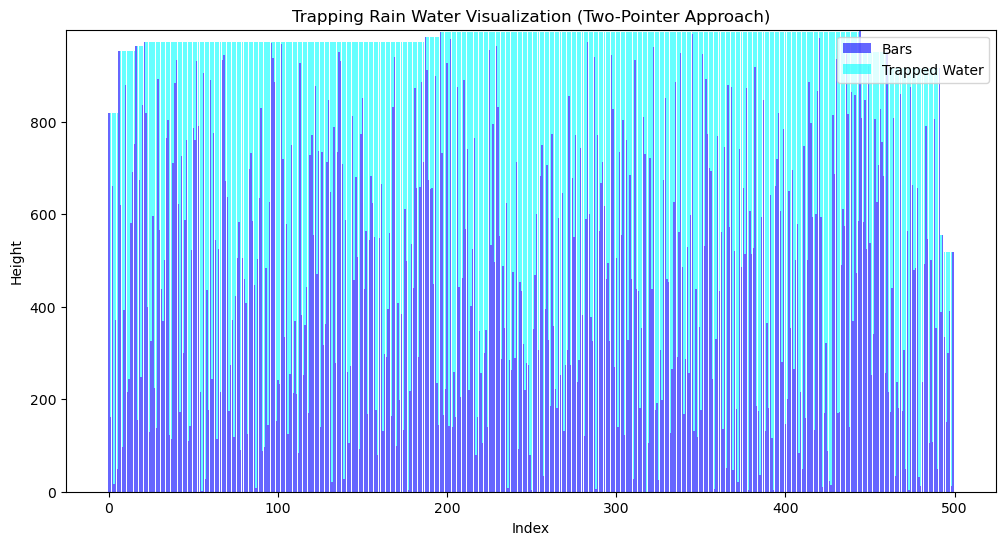

In [12]:
# Generating a massive dataset with 1,000,000 elements for visualization in chunks
large_heights_chunked = large_heights_extreme[:500]  # Visualizing only first 500 for clarity

# Visualizing the first 500 elements of the massive dataset
visualize_trapping_rainwater(large_heights_chunked)

Visualization of Trapped Water for Large Dataset (First 500 Elements)
  - This graph represents the first 500 elements of the 1,000,000-element dataset.
  - Blue bars are terrain heights.
  - Cyan regions show trapped rainwater in valleys.

### This will continue in trap_rainwater.py as a project